# TP 1

## Ejercicio 1a)

In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

In [9]:
def white_patch(img_bgr, p=95):

    img = img_bgr.astype(np.float32)
    #Trabajo con un percentil alto en vez de usar el maximo absoluto para que el White Patch no falle
    ref_b = np.percentile(img[:, :, 0], p)
    ref_g = np.percentile(img[:, :, 1], p)
    ref_r = np.percentile(img[:, :, 2], p)

    ref_b = max(ref_b, 1e-6)
    ref_g = max(ref_g, 1e-6)
    ref_r = max(ref_r, 1e-6)

    img[:, :, 0] *= 255.0 / ref_b
    img[:, :, 1] *= 255.0 / ref_g
    img[:, :, 2] *= 255.0 / ref_r

    return np.clip(img, 0, 255).astype(np.uint8)

In [10]:
carpeta_entrada = "white_patch"
carpeta_salida = "imagenes procesadas"

os.makedirs(carpeta_salida, exist_ok=True)

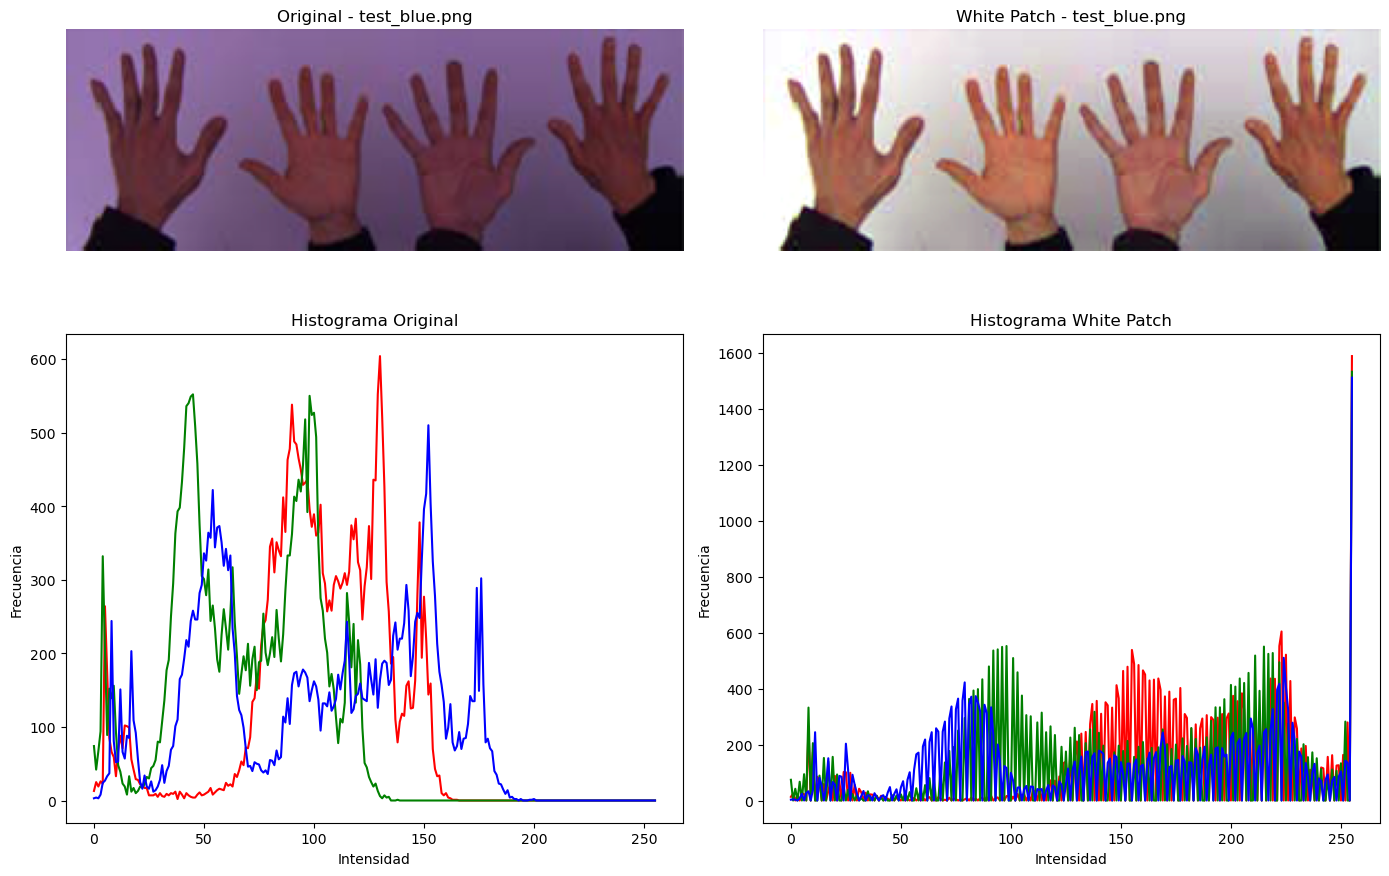

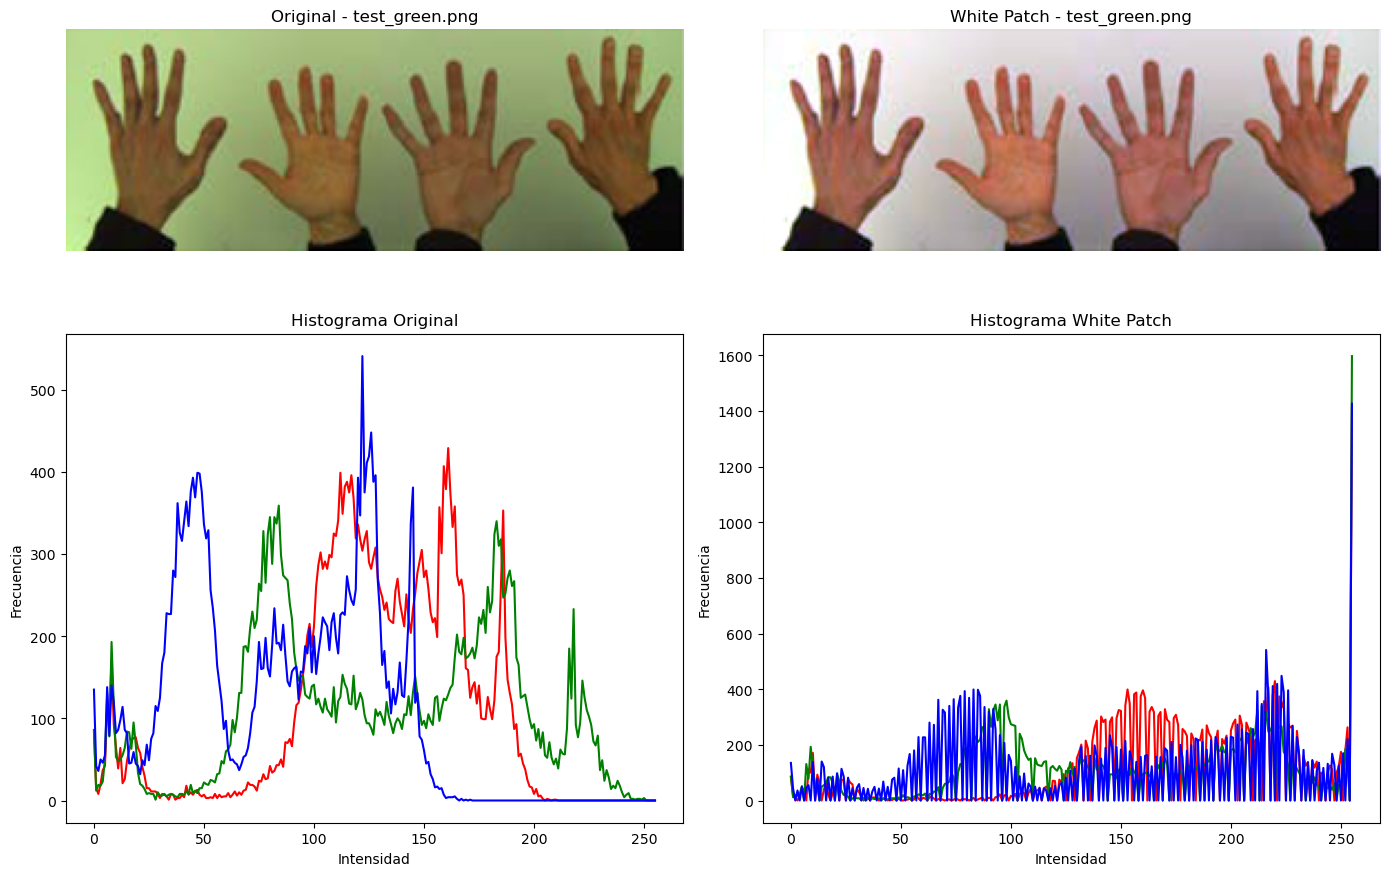

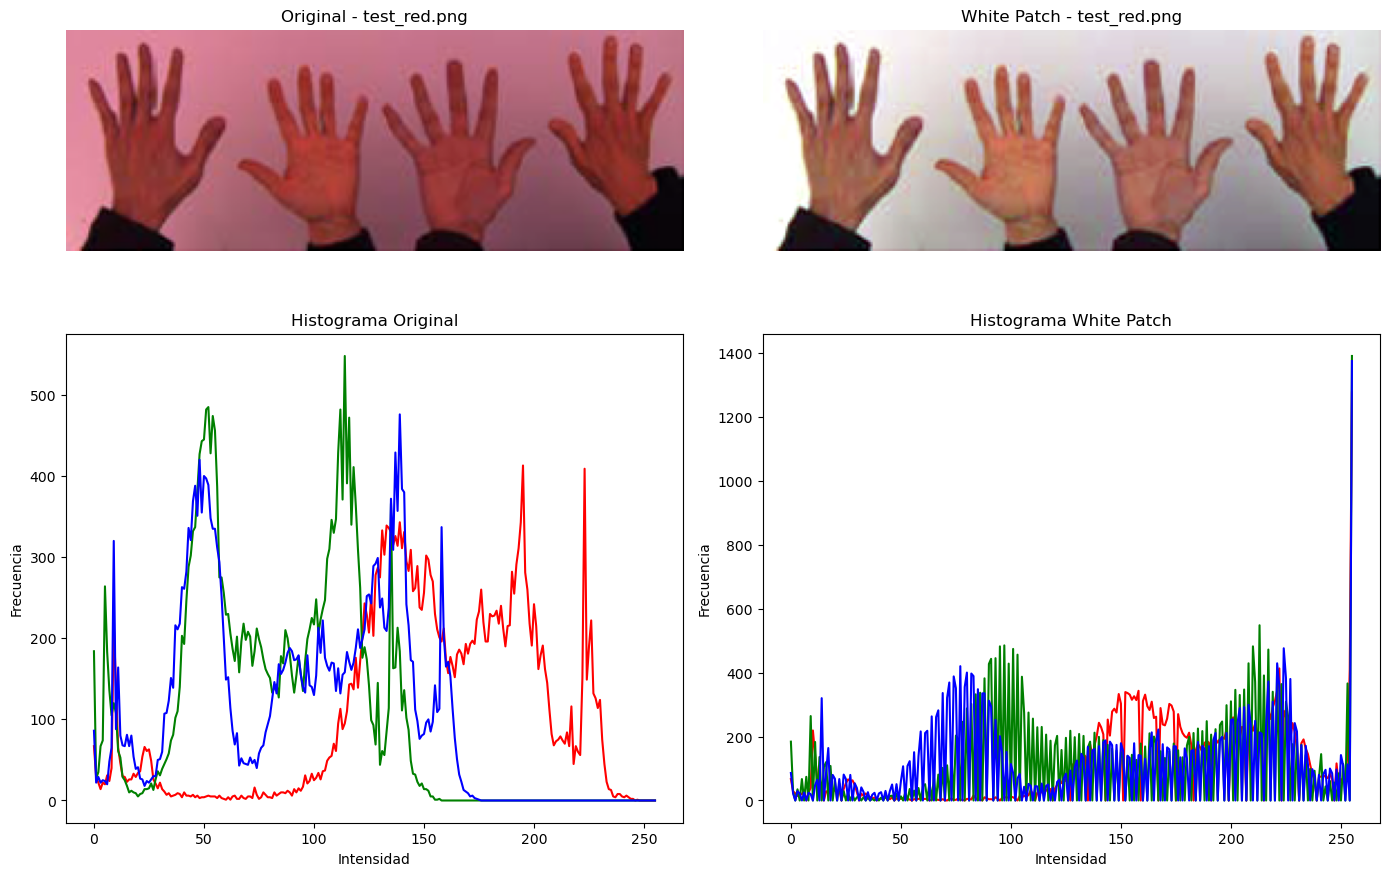

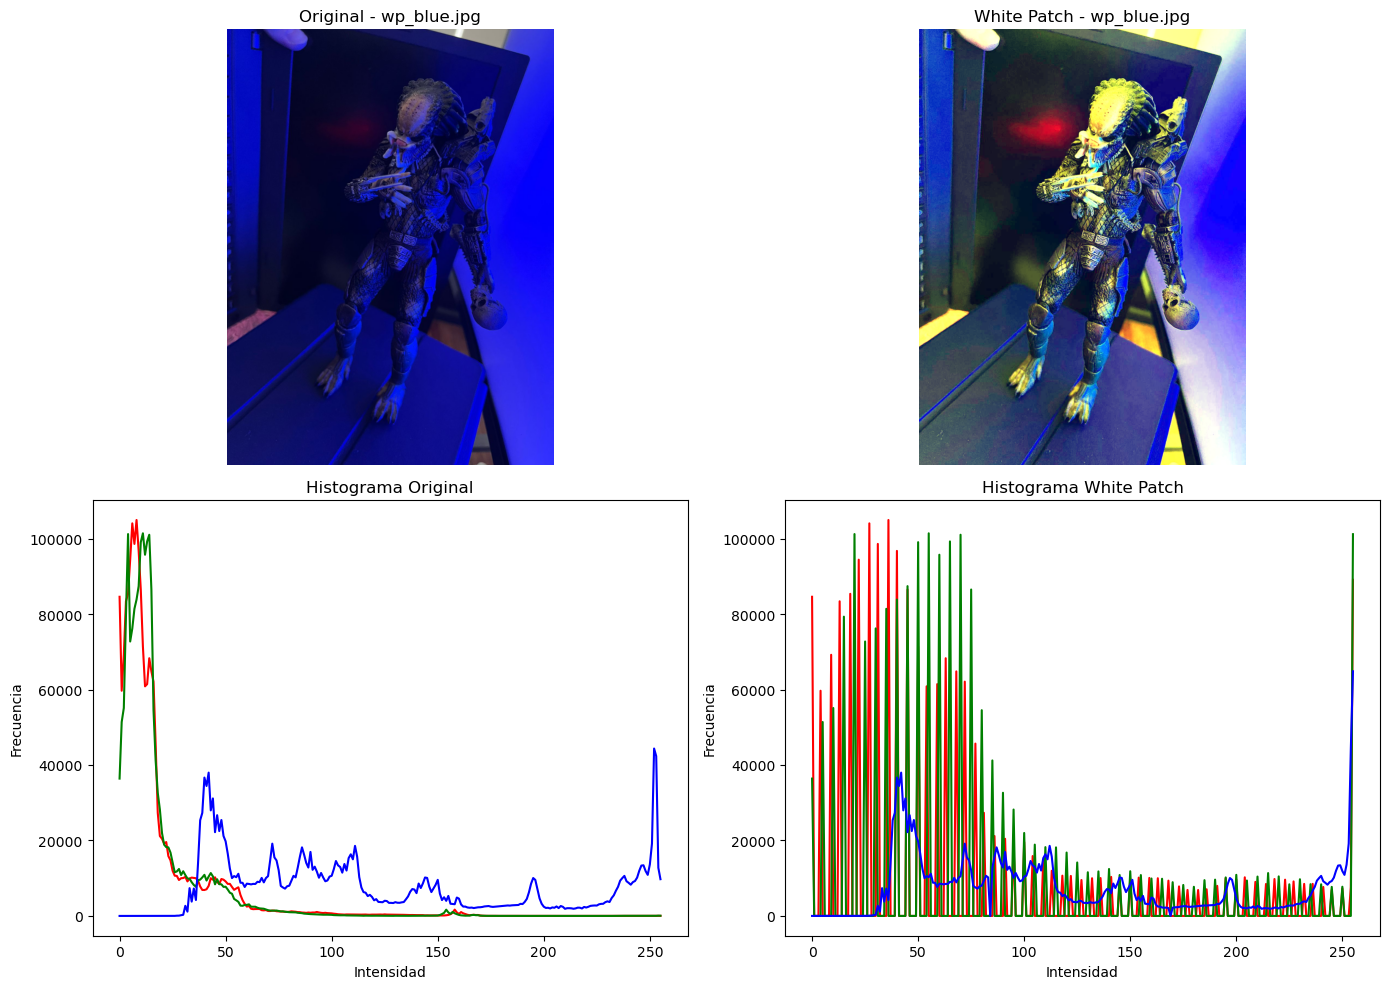

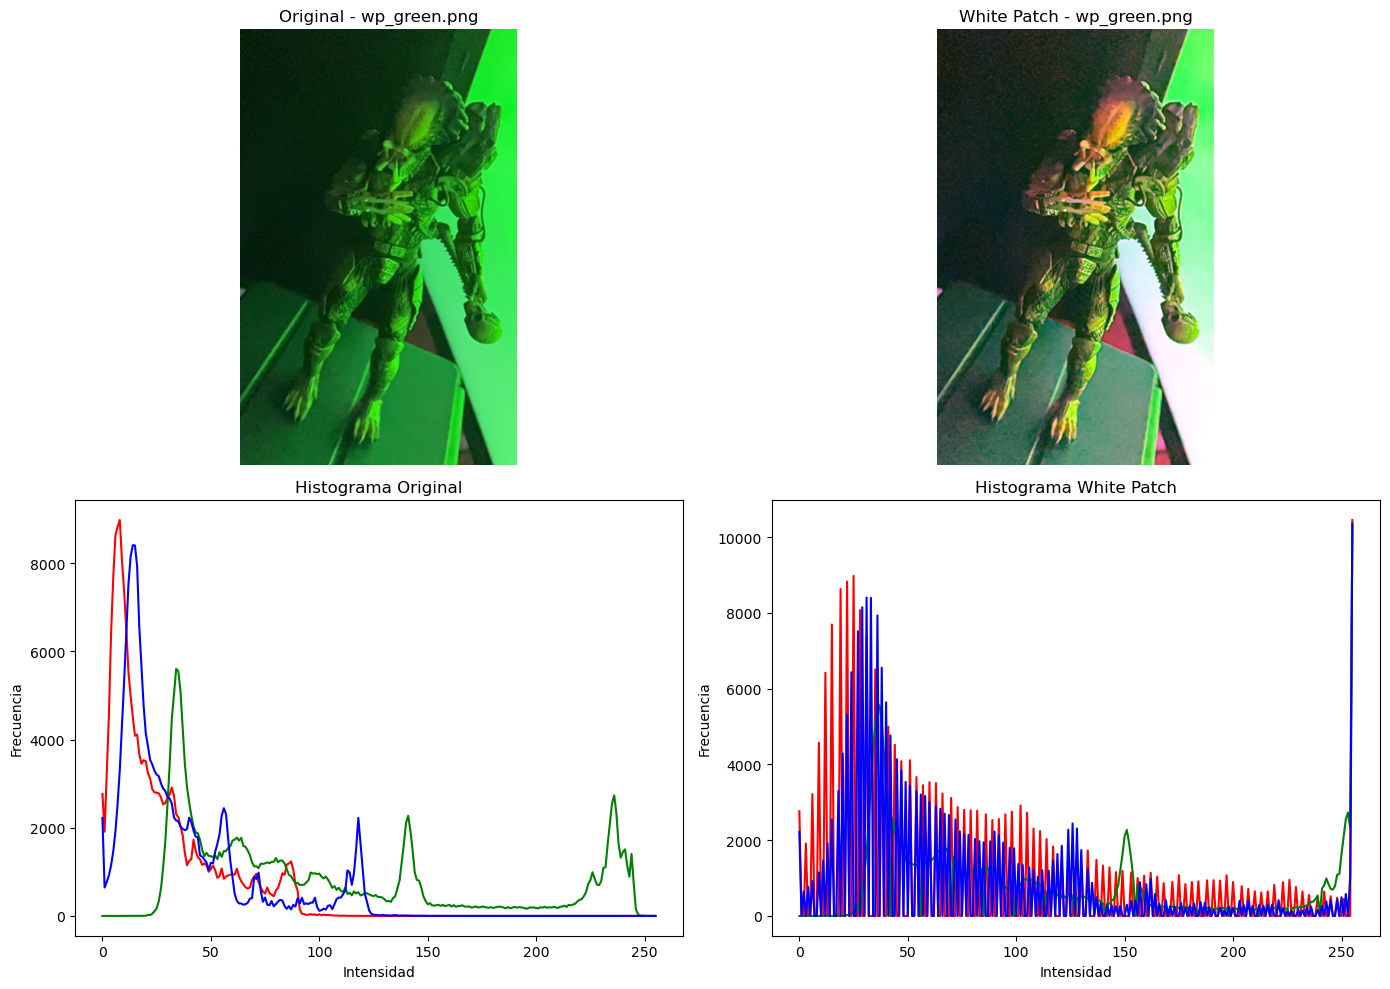

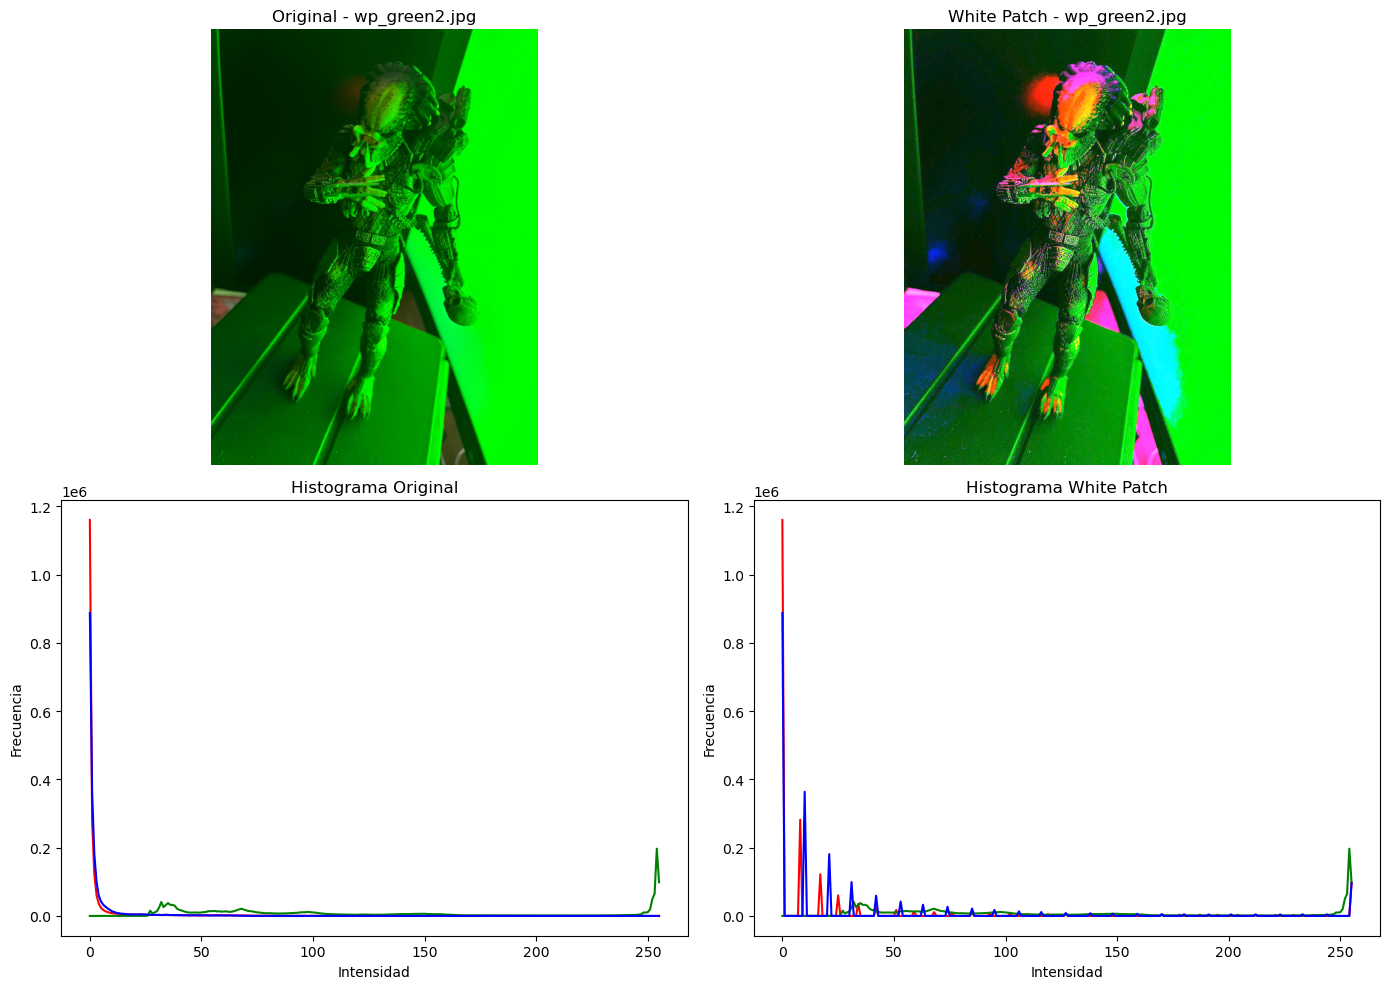

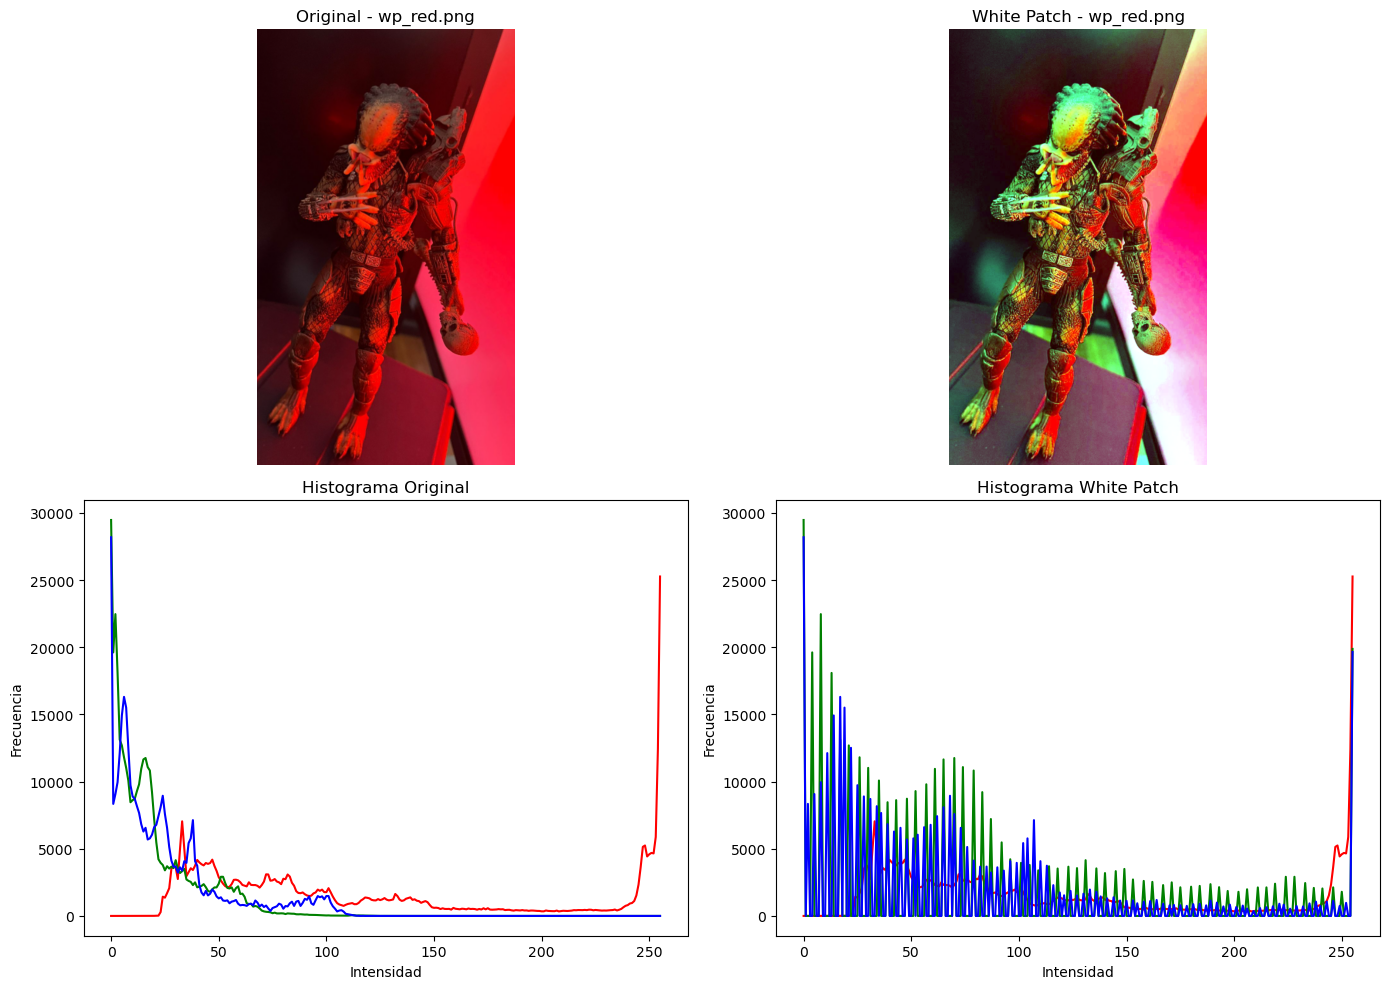

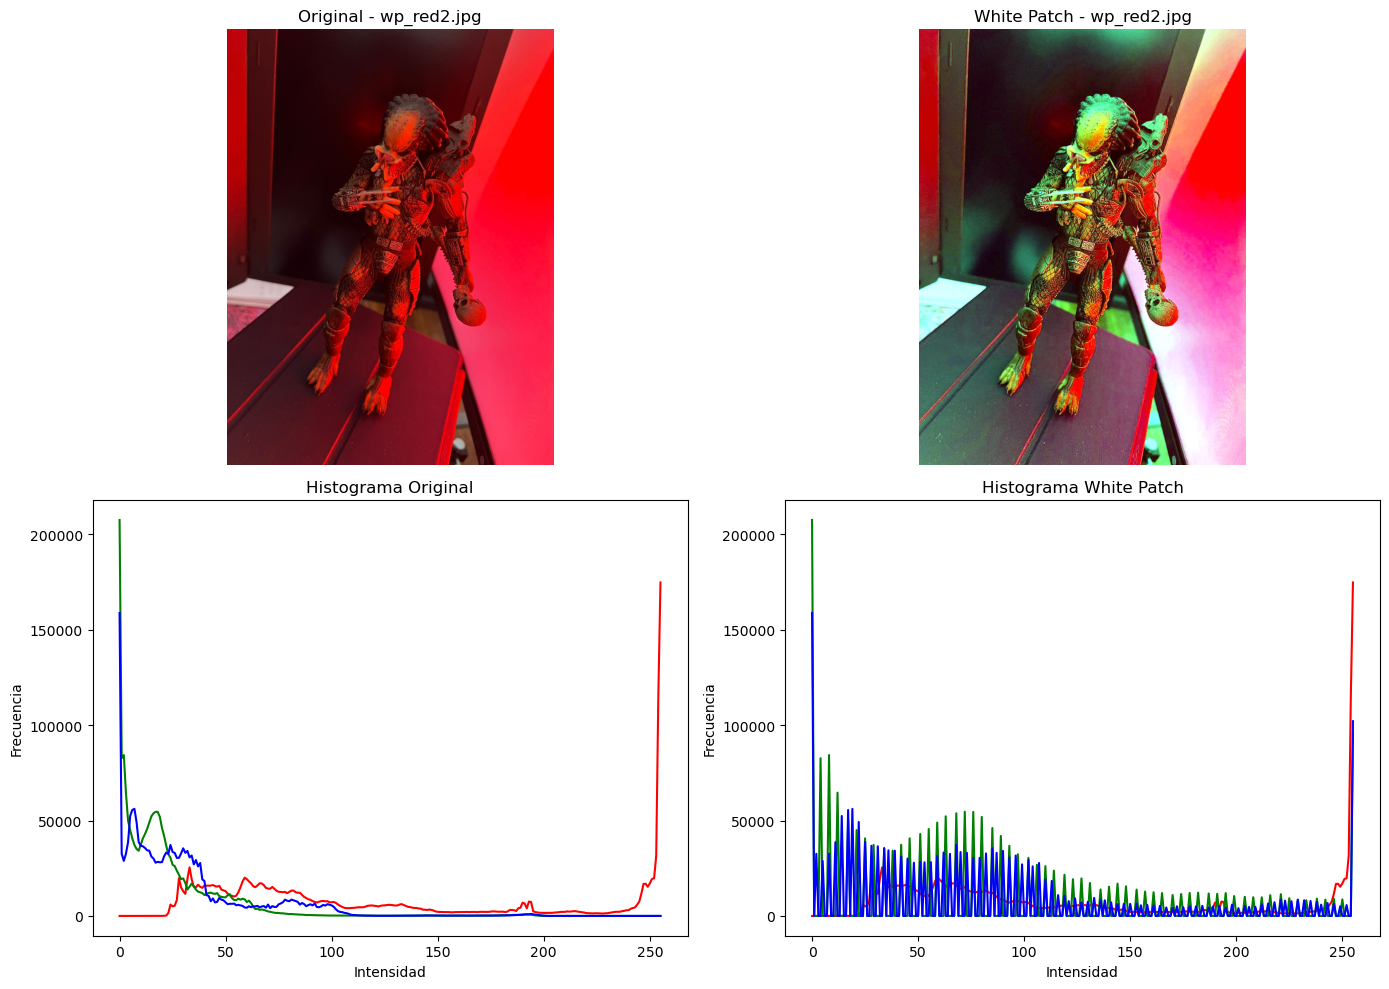

In [11]:
for archivo in os.listdir(carpeta_entrada):

    if archivo.endswith((".jpg", ".png", ".jpeg")):

        ruta = os.path.join(carpeta_entrada, archivo)
        img = cv.imread(ruta)

        if img is None:
            print(f"Error cargando {archivo}")
            continue

        # Aplico White Patch
        img_wp = white_patch(img)

        nombre, ext = os.path.splitext(archivo)
        ruta_salida = os.path.join(carpeta_salida, f"{nombre}_wp{ext}")
        cv.imwrite(ruta_salida, img_wp)

        img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        img_wp_rgb = cv.cvtColor(img_wp, cv.COLOR_BGR2RGB)

        plt.figure(figsize=(14, 10))
        
        #Grafico imagen original
        plt.subplot(2, 2, 1)
        plt.imshow(img_rgb)
        plt.title(f"Original - {archivo}")
        plt.axis("off")

        #Grafico imagen procesada por White Patch
        plt.subplot(2, 2, 2)
        plt.imshow(img_wp_rgb)
        plt.title(f"White Patch - {archivo}")
        plt.axis("off")

        # Histograma de la imagen original
        plt.subplot(2, 2, 3)
        for i, color in enumerate(("r", "g", "b")):
            hist = cv.calcHist([img_rgb], [i], None, [256], [0, 256])
            plt.plot(hist, color=color)
        plt.title("Histograma Original")
        plt.xlabel("Intensidad")
        plt.ylabel("Frecuencia")

        # Histograma de la imagen procesada
        plt.subplot(2, 2, 4)
        for i, color in enumerate(("r", "g", "b")):
            hist = cv.calcHist([img_wp_rgb], [i], None, [256], [0, 256])
            plt.plot(hist, color=color)
        plt.title("Histograma White Patch")
        plt.xlabel("Intensidad")
        plt.ylabel("Frecuencia")

        plt.tight_layout()
        plt.show()


## Ejercicio 1b)

 En las imagenes de las manos podemos observar que hay un excelente funcionamiento del algoritmo de White Patch. En las imagenes originales, los histogramas RGB muestran un debalance significativo pero al normalizar cada canal respecto a su máximo, los histogramas se reescalan y tienden a alinearse en el rango alto de intensidades (color blanco).

 Mientras que en las fotos del depredador, al tener fondo oscuro y saturación de algunos colores, afectan el buen funcionamiento de White Patch. En estos casos, los máximos de los colores no provienen de una referencia blanca real sino de regiones saturadas. Por lo tanto, la normalización genera un resultado inadecuado y no logra recuperar los colores reales.

## Ejercicio 2a)

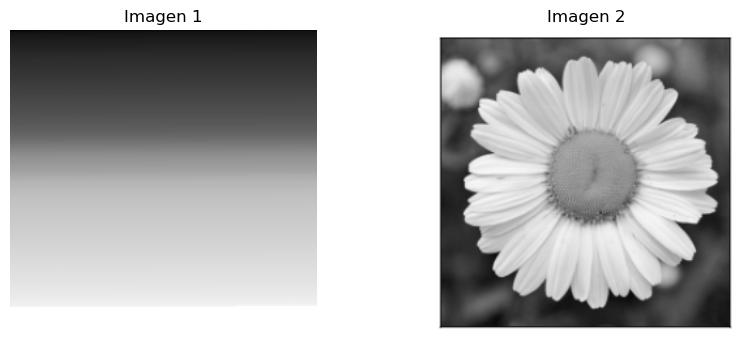

In [12]:
import cv2
#Leo las imagenes en escala de grises
im1 = cv2.imread('img1_tp.png', cv2.IMREAD_GRAYSCALE)
im2 = cv2.imread('img2_tp.png', cv2.IMREAD_GRAYSCALE)

#Imagen 1
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(im1, cmap='gray')
plt.title('Imagen 1')
plt.axis('off')
#Imagen 2
plt.subplot(1,2,2)
plt.imshow(im2, cmap='gray')
plt.title('Imagen 2')
plt.axis('off')
    
plt.show()

## Ejercicio 2b)

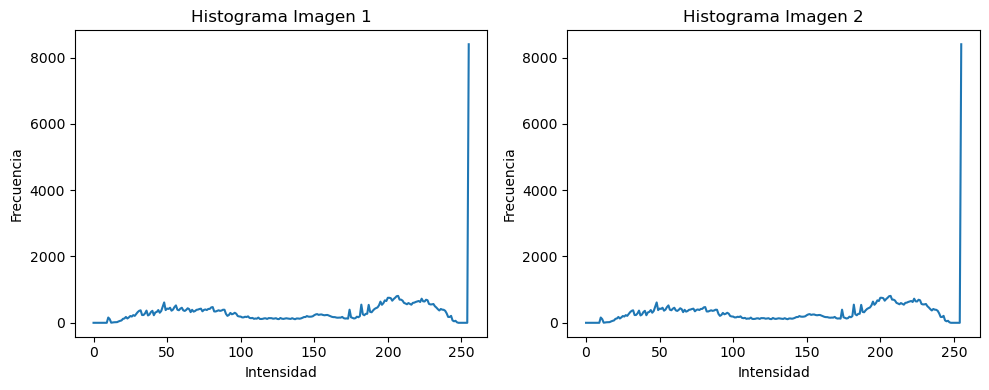

In [13]:
#Utilizo 256 bins que es lo estándar
hist1 = cv2.calcHist([im1], [0], None, [256], [0,256])
hist2 = cv2.calcHist([im2], [0], None, [256], [0,256])

# Plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(hist1)
plt.title('Histograma Imagen 1')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')

plt.subplot(1,2,2)
plt.plot(hist2)
plt.title('Histograma Imagen 2')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

En esta imagenes, podemos observar que si bien las imagenes son completamente distintas, poseen el mismo histograma. Esto se debe a que los histogramas no nos brindan información espacial de las imágenes.

Al momento de realizar un modelo de clasificación/detección de imágenes, tomar a los histogramas como "features" puede ser de utilidad pero, siempre y cuando, se utilicen a los mismos no como features principales sino como features complementarios. 